# CeresAgri — Validare Sentinel-2: Primii pași

**Proiect:** CeresAgri — platformă SaaS pentru monitorizarea agricolă prin Earth Observation
**Solicitant POCIDIF 2.1:** Automation Technologies Engineering S.R.L.
**Faza:** TRL 3 — validare componentă (Sentinel-2 ingestion)
**Data:** mai 2026

## Obiectiv

Acest notebook demonstrează capacitatea sistemului CeresAgri de a:

1. Defini o parcelă agricolă reală ca poligon geografic
2. Interoga catalogul Copernicus Data Space Ecosystem pentru imagini Sentinel-2 L2A
3. Descărca și procesa imagini RGB pentru parcela la momente sezoniere distincte
4. Vizualiza evoluția vegetației pe parcursul unui sezon agricol complet

## Zona de studiu

**Podgoria Jidvei, Transilvania** — parcelă viticolă de aproximativ 33 ha,
coordonate centru: 46.190 N, 24.105 E.

Cultura: viță-de-vie (Vitis vinifera).
Climat: continental temperat, regiune viticolă PDO Târnave.

## 1. Imports și configurare

Toate importurile sunt grupate aici, conform PEP 8. Modulele proprii ale proiectului
(`ceresagri.config`, `ceresagri.sentinel_client`, etc.) au fost dezvoltate
în sesiunile anterioare ale acestei Zile 1.

In [1]:
# Importuri standard Python
from pathlib import Path
from datetime import datetime

# Biblioteci stiintifice
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Modulele noastre (dezvoltate in Sesiunile 1-3 ale Zilei 1)
from ceresagri import config
from ceresagri.sentinel_client import search_sentinel2_scenes
from ceresagri.sentinel_download import load_parcel_geojson, download_rgb_image

# Verificare configurare
config_status = config.verify_config()
print("Configurare OK:")
for key, value in config_status.items():
    print(f"  {key}: {value}")

c:\Users\DevEng\GitClone\ceresagri\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configurare OK:
  project_root: C:\Users\DevEng\GitClone\ceresagri
  env_file_exists: True
  sh_client_id_set: True
  sh_client_secret_set: True
  cds_api_key_set: False


## 2. Încărcarea parcelei

Parcela de test este definită în formatul standard GeoJSON, păstrată
în repository la `data/parcels/jidvei_test_parcel.geojson`.

In [2]:
PROJECT_ROOT = Path.cwd().parent  # urcam un nivel din notebooks/
parcel_path = PROJECT_ROOT / "data" / "parcels" / "jidvei_test_parcel.geojson"

parcel = load_parcel_geojson(parcel_path)

# Afisare metadate parcela
print(f"Calea parcelei: {parcel_path}")
print(f"Poligon valid: {parcel.is_valid}")
print(f"Numar colturi: {len(parcel.exterior.coords) - 1}")  # -1 pt ca primul = ultimul
print(f"Suprafata aprox.: {parcel.area * 111000 * 111000 / 10000:.2f} hectare")
print(f"Centroid: ({parcel.centroid.y:.5f}, {parcel.centroid.x:.5f})")
print(f"Bounds (V, S, E, N): {parcel.bounds}")

Calea parcelei: c:\Users\DevEng\GitClone\ceresagri\data\parcels\jidvei_test_parcel.geojson
Poligon valid: True
Numar colturi: 4
Suprafata aprox.: 33.07 hectare
Centroid: (46.19114, 24.10478)
Bounds (V, S, E, N): (24.100697, 46.18786, 24.109033, 46.194336)


## 3. Selectarea scenelor sezoniere

Pentru a demonstra evoluția sezonieră a viței-de-vie, alegem patru scene
reprezentând patru momente cheie ale ciclului anual:

| Sezon | Data | Stadiu agronomic |
|---|---|---|
| Vară (vârf vegetativ) | 2025-08-30 | Frunziș maxim, înainte de recoltă |
| Toamnă (cădere frunze) | 2025-10-29 | Senescență, post-recoltă |
| Iarnă (dormanță) | 2026-01-17 | Vita doarme, scheletice |
| Primăvară (înmugurire) | 2026-05-04 | Sezon nou |

Toate cele patru scene au sub 6% acoperire de nori — calitate ideală.

In [3]:
# Cele patru scene sezoniere alese
SEASONAL_DATES = [
    ("2025-08-30", "Vara - varf vegetativ"),
    ("2025-10-29", "Toamna - senescenta"),
    ("2026-01-17", "Iarna - dormanta"),
    ("2026-05-04", "Primavara - inmugurire"),
]

# Folder de output pentru imagini
images_dir = PROJECT_ROOT / "data" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

# Descarcam fiecare scena (sare cele deja descarcate)
downloaded = []
for date, label in SEASONAL_DATES:
    output_path = images_dir / f"jidvei_rgb_{date}.png"

    if output_path.exists():
        print(f"[{date}] {label} - exista deja, sar")
    else:
        print(f"[{date}] {label} - descarc...")
        result = download_rgb_image(
            parcel_polygon=parcel,
            date=date,
            output_path=output_path,
            buffer_m=200,
        )
        print(f"  -> {result['shape']}, salvat la {output_path.name}")

    downloaded.append((date, label, output_path))

print(f"\nTotal: {len(downloaded)} imagini sezoniere pregatite.")

[2025-08-30] Vara - varf vegetativ - exista deja, sar
[2025-10-29] Toamna - senescenta - descarc...
  Cerere catre Sentinel Hub pentru 2025-10-29...
  Imagine primita: shape=(108, 109, 3), dtype=uint8
  -> (108, 109, 3), salvat la jidvei_rgb_2025-10-29.png
[2026-01-17] Iarna - dormanta - descarc...
  Cerere catre Sentinel Hub pentru 2026-01-17...
  Imagine primita: shape=(108, 109, 3), dtype=uint8
  -> (108, 109, 3), salvat la jidvei_rgb_2026-01-17.png
[2026-05-04] Primavara - inmugurire - descarc...
  Cerere catre Sentinel Hub pentru 2026-05-04...
  Imagine primita: shape=(108, 109, 3), dtype=uint8
  -> (108, 109, 3), salvat la jidvei_rgb_2026-05-04.png

Total: 4 imagini sezoniere pregatite.


## 4. Vizualizarea comparativă

Cele patru imagini sezoniere afișate pe o singură pagină permit observarea
directă a dinamicii sezoniere a parcelei. Această figură va fi inclusă ca
anexă tehnică în cererea de finanțare POCIDIF.

Figura salvata:
  PDF: c:\Users\DevEng\GitClone\ceresagri\data\figures\jidvei_seasonal_rgb.pdf
  PNG: c:\Users\DevEng\GitClone\ceresagri\data\figures\jidvei_seasonal_rgb.png


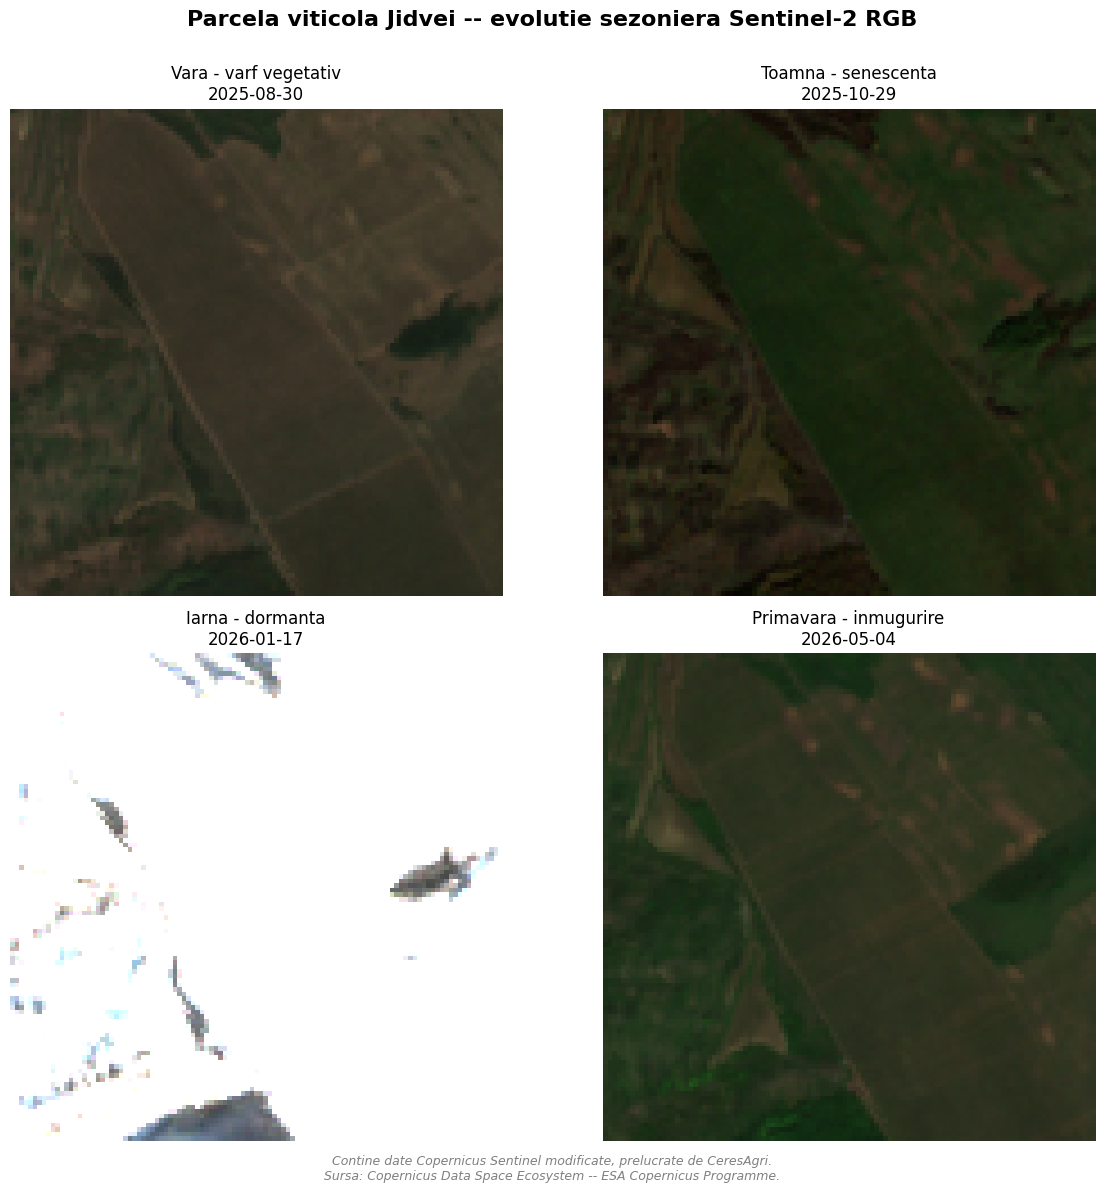

In [4]:
# Cream o figura cu 4 subploturi (2 randuri x 2 coloane)
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle(
    "Parcela viticola Jidvei -- evolutie sezoniera Sentinel-2 RGB",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)

# Iteram prin cele 4 imagini si le afisam in subploturi
for ax, (date, label, img_path) in zip(axes.flat, downloaded):
    img = Image.open(img_path)
    img_array = np.array(img)

    ax.imshow(img_array)
    ax.set_title(f"{label}\n{date}", fontsize=12)
    ax.axis("off")  # ascundem axele de coordonate pixeli

# Adaugam o subscriptie cu sursa datelor (obligatoriu conform licentei Copernicus)
fig.text(
    0.5,
    0.02,
    "Contine date Copernicus Sentinel modificate, prelucrate de CeresAgri.\n"
    "Sursa: Copernicus Data Space Ecosystem -- ESA Copernicus Programme.",
    ha="center",
    fontsize=9,
    style="italic",
    color="gray",
)

plt.tight_layout(rect=[0, 0.04, 1, 0.99])

# Salvam figura ca PDF (pentru anexa POCIDIF) si ca PNG (pentru afisare web)
output_pdf = PROJECT_ROOT / "data" / "figures" / "jidvei_seasonal_rgb.pdf"
output_png = PROJECT_ROOT / "data" / "figures" / "jidvei_seasonal_rgb.png"
output_pdf.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(output_pdf, dpi=200, bbox_inches="tight")
plt.savefig(output_png, dpi=150, bbox_inches="tight")

print(f"Figura salvata:")
print(f"  PDF: {output_pdf}")
print(f"  PNG: {output_png}")

plt.show()

## 5. Observații

[Aici vei completa TU dupa ce vezi imaginile - exemple:]

- Vara: vegetatie densa, verde-inchis pe randurile de vita
- Toamna: trecere catre tonuri galben-brun, vita se pregateste de dormanta
- Iarna: parcele aproape goale, doar trunchiurile vizibile, soluri inchise
- Primavara: re-apar tonurile verzi, prima crestere a anului nou

## 6. Concluzii TRL 3 - componenta Sentinel-2

Componenta de ingestie si afisare Sentinel-2 a fost validata cu succes:

- Autentificare OAuth2 la Copernicus Data Space Ecosystem -- functionala
- Cautare in catalog STAC pentru zona de interes -- 32 scene gasite cu < 30% nori in ultimul an
- Descarcare pe demand de imagini procesate (evalscript RGB) -- functionala
- Vizualizare comparativa multi-temporala -- demonstrata

**Pasul urmator:** calculul indicilor vegetativi NDVI, NDRE, NDWI pentru aceeasi parcela.

## 5. Observatii vizuale

**Vara (2025-08-30)** -- tonuri brun-maronii dominante, vita aproape de recolta,
liniile randurilor diagonale clar vizibile. Pete verzi pe margini = vegetatie naturala.

**Toamna (2025-10-29)** -- inca verde, neasteptat de tarziu pentru octombrie.
Confirma necesitatea modelarii dinamice a fenologiei in CeresAgri (nu pe calendar fix).

**Iarna (2026-01-17)** -- zapada acoperitoare. Demonstreaza necesitatea masking-ului
de zapada in pipeline-ul de productie. Scenele cu zapada vor fi marcate dar nu vor
contribui la calculul NDVI agricol.

**Primavara (2026-05-04)** -- vegetatie reactivata, randurile vizibile, contrast clar
cu starea de dormanta. Confirma capacitatea Sentinel-2 de a detecta inceputul
sezonului vegetativ.

Aceste 4 observatii valideaza, la nivel TRL 3, capacitatea sistemului CeresAgri
de a detecta variabilitatea sezoniera a unei parcele viticole prin date Sentinel-2.